Tailles de réseau détectées : [2, 4, 8, 16, 32, 64, 128]

===== Traitement L = 2 =====
τ_int(L=2) = 4.0205
Burn-in appliqué : 20 steps

===== Traitement L = 4 =====
τ_int(L=4) = 20.6027
Burn-in appliqué : 103 steps

===== Traitement L = 8 =====
τ_int(L=8) = 79.7800
Burn-in appliqué : 398 steps

===== Traitement L = 16 =====
τ_int(L=16) = 298.6562
Burn-in appliqué : 1493 steps

===== Traitement L = 32 =====
τ_int(L=32) = 939.9907
Burn-in appliqué : 4699 steps

===== Traitement L = 64 =====
τ_int(L=64) = 2161.9561
Burn-in appliqué : 10809 steps

===== Traitement L = 128 =====
τ_int(L=128) = 10400.7557
Burn-in appliqué : 52003 steps

    Exposant dynamique estimé : z = 1.821
    Coefficient de corrélation R² = 0.9936



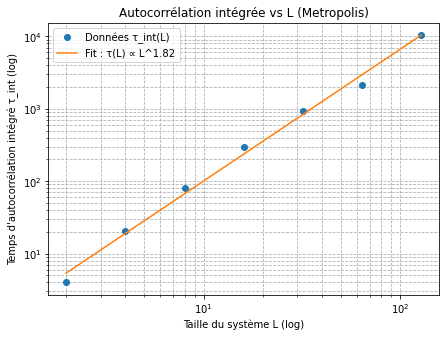

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from scipy.stats import linregress

############################################################
# Autocorrelation utilities
############################################################

def autocorrelation(data):
    n = len(data)
    m = np.mean(data)
    v = np.var(data)

    if v == 0:
        return np.ones(n)

    ac = np.correlate(data - m, data - m, mode='full')[n-1:] / (v * n)
    return ac

def integrated_autocorrelation_time(autocorr):
    negative = np.where(autocorr < 0)[0]

    if len(negative) == 0:
        W = len(autocorr)
    else:
        W = 3 * negative[0]

    tau = 0.5 + np.sum(autocorr[1:W])
    return tau

############################################################
# Automatic detection of available L
############################################################

base_dir = "data/Metropolis_Temp_Scan"
beta_c = 0.4407
h = 0.0

L_list = []

for folder in os.listdir(base_dir):
    m = re.match(r"L_(\d+)", folder)
    if m:
        L_list.append(int(m.group(1)))

L_list = sorted(L_list)
print("Tailles de réseau détectées :", L_list)

############################################################
# Compute τ_int(L) for each detected L with burn-in
############################################################

tau_vs_L = []

for L in L_list:
    print(f"\n===== Traitement L = {L} =====")

    file_path = f"{base_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"

    if not os.path.exists(file_path):
        print(f"⚠️  Fichier indisponible : {file_path}")
        continue

    # Load energies + magnetizations
    data = np.load(file_path)
    energies = data["energies"]
    mags     = data["magnetizations"]

    # --- Calculer τ_int sur la série complète (avant burn-in) ---
    observable = mags  # <--- ou mags si tu veux
    ac = autocorrelation(observable)
    tau = integrated_autocorrelation_time(ac)
    print(f"τ_int(L={L}) = {tau:.4f}")

    # --- Appliquer burn-in basé sur τ_int (5 * τ_int) ---
    burn_in = int(5 * tau)
    if burn_in >= len(energies):
        print(f"⚠️ Burn-in trop grand pour L={L}, on ne tronque pas")
        burn_in = 0

    energies = energies[burn_in:]
    mags     = mags[burn_in:]

    print(f"Burn-in appliqué : {burn_in} steps")
    tau_vs_L.append((L, tau))

############################################################
# Convert to arrays
############################################################

tau_vs_L = np.array(tau_vs_L)
Ls = tau_vs_L[:,0]
taus = tau_vs_L[:,1]

############################################################
# Fit log-log to extract z
############################################################

logL = np.log(Ls)
logtau = np.log(taus)

slope, intercept, r_value, p_value, std_err = linregress(logL, logtau)
z_estimate = slope

print("\n======================================")
print(f"    Exposant dynamique estimé : z = {z_estimate:.3f}")
print(f"    Coefficient de corrélation R² = {r_value**2:.4f}")
print("======================================\n")

############################################################
# Plot log-log graph
############################################################

plt.figure(figsize=(7,5))
plt.plot(Ls, taus, 'o', label="Données τ_int(L)")
plt.plot(Ls, np.exp(intercept) * Ls**z_estimate,
         label=f"Fit : τ(L) ∝ L^{z_estimate:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Taille du système L (log)")
plt.ylabel("Temps d'autocorrélation intégré τ_int (log)")
plt.title("Autocorrélation intégrée vs L (Metropolis)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


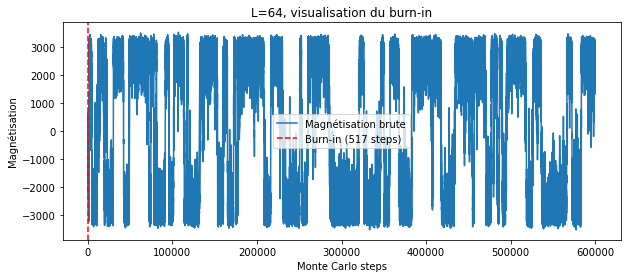

In [8]:
import matplotlib.pyplot as plt

# Exemple pour un L spécifique
L = 64  # change pour tester d'autres L
file_path = f"{base_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
data = np.load(file_path)
mags = data["magnetizations"]

# Calcul du burn-in (5 * tau_int)
tau_int = 103.4803  # ou récupère-le depuis ton calcul
burn_in = int(5 * tau_int)

plt.figure(figsize=(10,4))
plt.plot(mags, label="Magnétisation brute")
plt.axvline(burn_in, color='red', linestyle='--', label=f"Burn-in ({burn_in} steps)")
plt.xlabel("Monte Carlo steps")
plt.ylabel("Magnétisation")
plt.title(f"L={L}, visualisation du burn-in")
plt.legend()
plt.show()
